In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

with open("data/cloudtrail/sample_cloudtrail.json") as f:
    data = json.load(f)

records = data["Records"]
df = pd.json_normalize(records)
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'data/cloudtrail/sample_cloudtrail.json'

In [2]:

import os, pathlib
print("cwd:", os.getcwd())
print("notebook file should be here:", pathlib.Path().resolve())
print("exists?", os.path.exists("data/cloudtrail/sample_cloudtrail.json"))


cwd: C:\Users\renee\OneDrive\Desktop\security-analytics-notebooks\notebooks
notebook file should be here: C:\Users\renee\OneDrive\Desktop\security-analytics-notebooks\notebooks
exists? False


In [3]:
import os
print("exists?", os.path.exists("../data/cloudtrail/sample_cloudtrail.json"))


exists? True


In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

with open("../data/cloudtrail/sample_cloudtrail.json", "r") as f:
    data = json.load(f)

records = data["Records"]
df = pd.json_normalize(records)
df.head()

,eventVersion,eventTime,eventSource,eventName,awsRegion,sourceIPAddress,userAgent,requestParameters,eventID,eventType,...,responseElements.ConsoleLogin,additionalEventData.MFAUsed,responseElements,userIdentity.sessionContext.sessionIssuer.userName,requestParameters.maxResults,requestParameters.bucketName,requestParameters.key,additionalEventData.SignatureVersion,requestParameters.userName,requestParameters.roleArn
0,1.08,2026-03-05T14:01:12Z,signin.amazonaws.com,ConsoleLogin,us-east-1,203.0.113.15,Mozilla/5.0,NaN,1111aaaa-bbbb-cccc-dddd-eeeeffff0001,AwsConsoleSignIn,...,Success,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.08,2026-03-05T14:05:40Z,ec2.amazonaws.com,DescribeInstances,us-east-1,198.51.100.25,aws-cli/2.13.0,NaN,1111aaaa-bbbb-cccc-dddd-eeeeffff0002,AwsApiCall,...,NaN,NaN,NaN,SecOpsRole,5.0,NaN,NaN,NaN,NaN,NaN
2,1.08,2026-03-05T14:08:05Z,s3.amazonaws.com,GetObject,us-east-1,203.0.113.15,aws-sdk-java/1.12,NaN,1111aaaa-bbbb-cccc-dddd-eeeeffff0003,AwsApiCall,...,NaN,NaN,NaN,NaN,NaN,corp-logs-archive,reports/weekly/report.csv,SigV4,NaN,NaN
3,1.08,2026-03-05T14:12:47Z,iam.amazonaws.com,CreateAccessKey,us-east-1,198.51.100.44,aws-cli/2.13.0,NaN,1111aaaa-bbbb-cccc-dddd-eeeeffff0004,AwsApiCall,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,temp-user,NaN
4,1.08,2026-03-05T14:16:22Z,sts.amazonaws.com,AssumeRole,us-east-1,203.0.113.15,aws-cli/2.13.0,NaN,1111aaaa-bbbb-cccc-dddd-eeeeffff0005,AwsApiCall,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,arn:aws:iam::111122223333:role/SecOpsRole


In [5]:
# Top API calls
df["eventName"].value_counts().head(10)
``


SyntaxError: invalid syntax (455598609.py, line 3)

In [6]:
# Top API calls
df["eventName"].value_counts().head(10)


eventName
ConsoleLogin         1
DescribeInstances    1
GetObject            1
CreateAccessKey      1
AssumeRole           1
Name: count, dtype: int64

In [7]:
# Events over time (hourly)
df["eventTime"] = pd.to_datetime(df["eventTime"])
df.set_index("eventTime")["eventName"].resample("1H").count().plot(
    figsize=(12,4), title="CloudTrail Events per Hour"
)

ValueError: Invalid frequency: 1H. Failed to parse with error message: ValueError("Invalid frequency: H. Failed to parse with error message: KeyError('H'). Did you mean h?")

C:\Users\renee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\plotting\_matplotlib\core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


<Axes: title={'center': 'CloudTrail Events per Hour'}, xlabel='eventTime'>

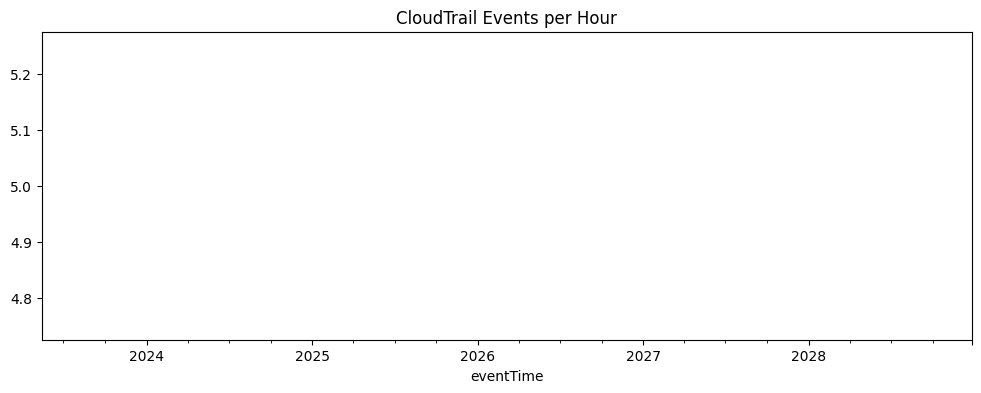

In [8]:
# Events over time (hourly)
df["eventTime"] = pd.to_datetime(df["eventTime"])
df.set_index("eventTime")["eventName"].resample("1h").count().plot(
    figsize=(12,4), title="CloudTrail Events per Hour"
)

In [9]:
# Top principals by activity
df["userIdentity.arn"].value_counts().head(10)

userIdentity.arn
arn:aws:iam::111122223333:user/alex                               3
arn:aws:sts::111122223333:assumed-role/SecOpsRole/security-ops    1
arn:aws:iam::111122223333:user/temp-user                          1
Name: count, dtype: int64

In [10]:
# Ensure eventTime is datetime and not empty
df["eventTime"] = pd.to_datetime(df["eventTime"], errors="coerce")
df = df.dropna(subset=["eventTime"])

# Aggregate by hour and plot cleanly
hourly = (
    df.set_index("eventTime")["eventName"]
      .resample("1H").count()
      .rename("events_per_hour")
)

ax = hourly.plot(figsize=(10,4), marker="o", lw=1, title="CloudTrail Events per Hour")
ax.set_xlabel("Time")
ax.set_ylabel("Events")
ax.grid(True, alpha=0.3)

ValueError: Invalid frequency: 1H. Failed to parse with error message: ValueError("Invalid frequency: H. Failed to parse with error message: KeyError('H'). Did you mean h?")

C:\Users\renee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\plotting\_matplotlib\core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


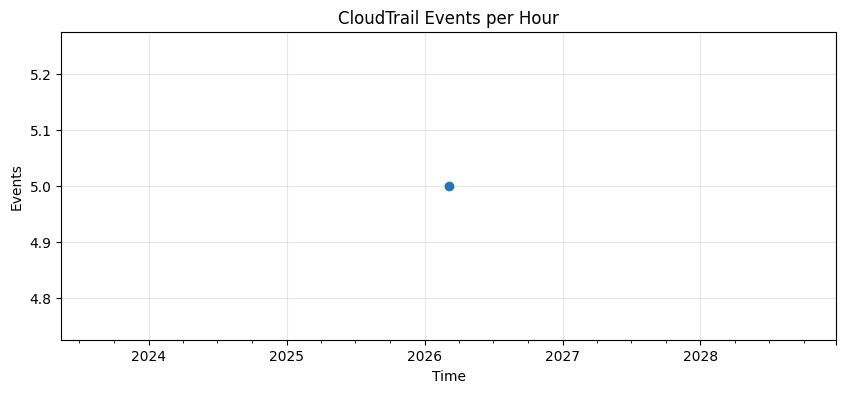

In [11]:
# Ensure eventTime is datetime and not empty
df["eventTime"] = pd.to_datetime(df["eventTime"], errors="coerce")
df = df.dropna(subset=["eventTime"])

# Aggregate by hour and plot cleanly
hourly = (
    df.set_index("eventTime")["eventName"]
      .resample("1h").count()
      .rename("events_per_hour")
)

ax = hourly.plot(figsize=(10,4), marker="o", lw=1, title="CloudTrail Events per Hour")
ax.set_xlabel("Time")
ax.set_ylabel("Events")
ax.grid(True, alpha=0.3)

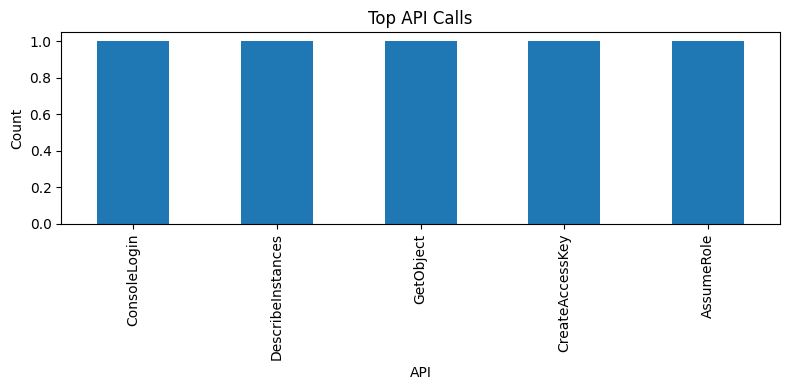

In [12]:
top_apis = df["eventName"].value_counts().head(10)
ax = top_apis.plot(kind="bar", figsize=(8,4), title="Top API Calls")
ax.set_xlabel("API")
ax.set_ylabel("Count")
plt.tight_layout()